In [16]:
!pip install numpy
!pip install torch
!pip install -q tqdm
!pip install matplotlib

In [17]:
import numpy as np
import torch
import torch.nn as nn
# import torch_xla
from tqdm import tqdm
from matplotlib import pyplot as plt

In [4]:
class PINN(nn.Module):
    def __init__(self, layers=None):
        super().__init__()
        if layers is None:
            layers = [2, 50, 50, 50, 50, 1]
        self.activation = nn.Tanh()
        self.layers = nn.ModuleList()

        for i in range(len(layers)-1):
            self.layers.append(nn.Linear(layers[i], layers[i+1]))

    def forward(self, x, t):
        inputs = torch.cat([x, t], dim=1)
        for layer in self.layers[:-1]:
            inputs = self.activation(layer(inputs))

        return self.layers[-1](inputs)

In [5]:
def compute_wave_equation_residue(model, x, t, c):
    psi = model(x, t)
    psi_t = torch.autograd.grad(psi, t, torch.ones_like(psi), create_graph=True, retain_graph=True)[0]
    psi_t_t = torch.autograd.grad(psi_t, t, torch.ones_like(psi_t), create_graph=True, retain_graph=True)[0]
    psi_x = torch.autograd.grad(psi, x, torch.ones_like(psi), create_graph=True, retain_graph=True)[0]
    psi_x_x = torch.autograd.grad(psi_x, x, torch.ones_like(psi_x), create_graph=True, retain_graph=True)[0]

    residue = psi_x_x - 1 / (c*c) * psi_t_t
    return (residue ** 2).mean()

In [6]:
def analytical_solution(x, t, c, A=1., L=1.):
    return A * np.sin(np.pi*x/L) * np.cos(np.pi*x*t/L)

In [7]:
# device = torch_xla.device()
device = torch.device("cuda")

In [8]:
n_colloc, n_bc = 5000, 200
epochs = 5000
A = 1.
L = 1.

In [9]:
x_colloc = torch.rand(n_colloc, 1, requires_grad=True).to(device)

In [10]:
t_colloc = torch.rand(n_colloc, 1, requires_grad=True).to(device)

In [11]:
# initial condition
x_ic = torch.rand(n_bc, 1).to(device)
t_ic = torch.zeros(n_bc, 1).to(device)
psi_ic = A * torch.sin(np.pi * x_ic / L)

In [12]:
# boundary conditions
x_bc = torch.cat([torch.zeros(n_bc // 2, 1), torch.ones(n_bc // 2, 1) * L]).to(device)
t_bc = torch.rand(n_bc, 1).to(device)
psi_bc = torch.zeros(n_bc, 1).to(device)

In [13]:
pinn = PINN().to(device)
optimizer = torch.optim.Adam(pinn.parameters(), lr=1e-3)

In [14]:
losses_pde = []
losses_ic = []
losses_bc = []

In [15]:
for epoch in tqdm(range(epochs)):
    optimizer.zero_grad()

    loss_pde = compute_wave_equation_residue(pinn, x_colloc, t_colloc, c=1.)
    loss_ic = nn.functional.mse_loss(pinn(x_ic, t_ic), psi_ic)
    loss_bc = nn.functional.mse_loss(pinn(x_bc, t_bc), psi_bc)

    loss = loss_pde + 10 * loss_ic + 10 * loss_bc

    loss.backward()
    optimizer.step()

    losses_pde.append(loss_pde.item())
    losses_ic.append(loss_ic.item())
    losses_bc.append(loss_bc.item())

    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch}: {loss.item():.2f}")

  0%|          | 0/5000 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
 11%|█         | 555/5000 [00:02<00:14, 307.71it/s]

Epoch 499: 0.01


 21%|██        | 1051/5000 [00:04<00:12, 306.65it/s]

Epoch 999: 0.00


 31%|███       | 1547/5000 [00:05<00:11, 307.39it/s]

...

Epoch 3999: 0.00


 91%|█████████ | 4549/5000 [00:15<00:01, 305.68it/s]

Epoch 4499: 0.00


100%|██████████| 5000/5000 [00:16<00:00, 295.35it/s]

Epoch 4999: 0.00


Text(0.5, 1.0, 'Loss (PDE residue)')

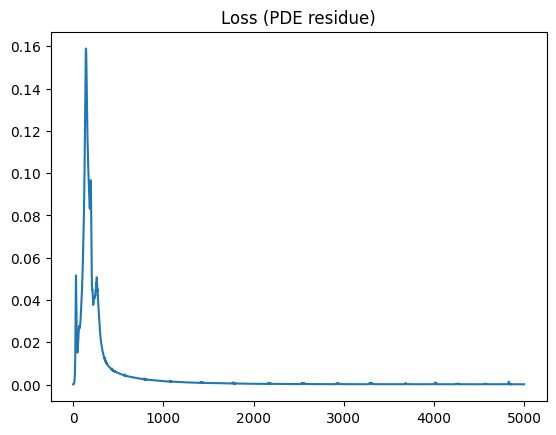

In [20]:
plt.plot(range(epochs), losses_pde)
plt.title("Loss (PDE residue)")

Text(0.5, 1.0, 'Loss (boundary condition)')

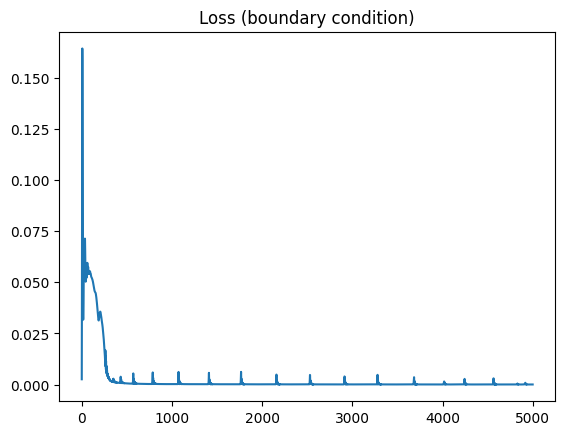

In [21]:
plt.plot(range(epochs), losses_bc)
plt.title("Loss (boundary condition)")

Text(0.5, 1.0, 'Loss (initial condition)')

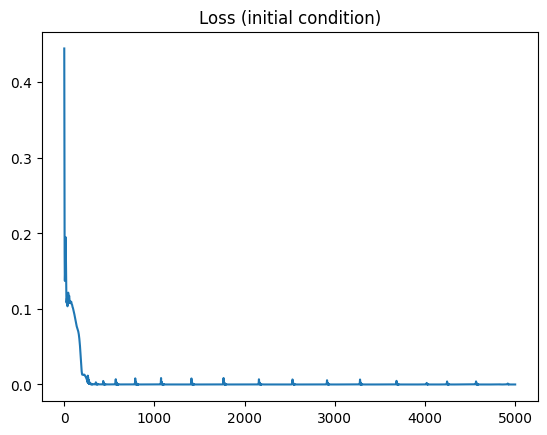

In [22]:
plt.plot(range(epochs), losses_ic)
plt.title("Loss (initial condition)")

In [29]:
nb_test = 100

x_test = np.linspace(0, 1, nb_test)
t_test = np.linspace(0, 1, nb_test)

In [30]:
X_test, T_test = np.meshgrid(x_test, t_test)

In [32]:
with torch.no_grad():
    X_flat = torch.FloatTensor(X_test.flatten()[:, None]).to(device)
    T_flat = torch.FloatTensor(T_test.flatten()[:, None]).to(device)
    psi_pred = pinn(X_flat, T_flat).cpu().numpy().reshape(nb_test, nb_test)

In [40]:
np.mean(np.square((psi_pred - analytical_solution(X_test, T_test, 1.0))))

np.float64(0.24883056654521724)